In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
from sklearn.pipeline import Pipeline

In [ ]:
df=pd.read_csv("/content/loan_approved (1).csv")

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


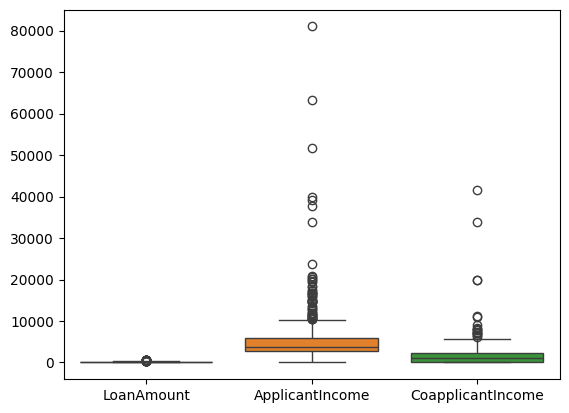

In [ ]:
sns.boxplot(df[['LoanAmount','ApplicantIncome','CoapplicantIncome']])
plt.show()

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

<Axes: >

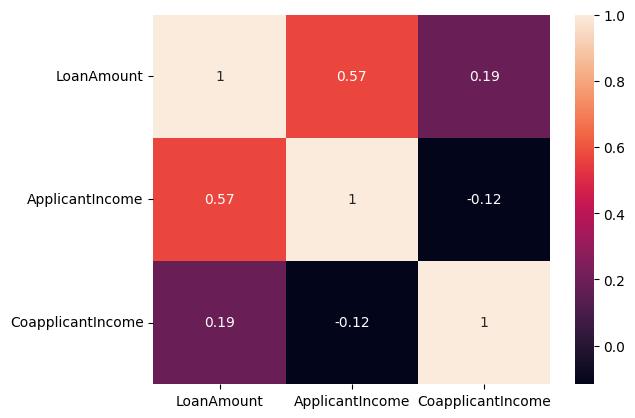

In [ ]:
sns.heatmap(df[['LoanAmount','ApplicantIncome','CoapplicantIncome']].corr(),annot=True)

In [ ]:
df['Married'].value_counts()

,count
Married,
Yes,398
No,213


In [ ]:
df["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [ ]:
df['Education'].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [ ]:
df['Self_Employed'].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [ ]:
df[['ApplicantIncome','CoapplicantIncome','LoanAmount']].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,592.000000
mean,5403.459283,1621.245798,146.412162
std,6109.041673,2926.248369,85.587325
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.000000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,168.000000
max,81000.000000,41667.000000,700.000000


In [ ]:
df['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [ ]:
df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [ ]:
def divide_by_12(x):
    return (x/12)

In [ ]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [ ]:
df['Property_Area'].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


In [ ]:
df['Loan_Status (Approved)'].value_counts()

,count
Loan_Status (Approved),
Y,422
N,192


In [ ]:
#Creating the Preprocessing Pipeline

#We need to impute Null values in the dataframe we will use simple imputers and we will have two categories here one with discrete null values and one with continuous null values
dis_null_cols=['Gender','Married','Dependents','Self_Employed','Loan_Amount_Term','Credit_History']
cont_null_cols=['LoanAmount']
OHE_columns=["Self_Employed",'Property_Area','Gender']
standard_scaler=["ApplicantIncome","CoapplicantIncome","LoanAmount"]
function_trasformer=["Loan_Amount_Term"]
label_encoder=["Married"]
pass_through=['Credit_History']
#we need to define ordinalencoder seperately for every column as we have to define the order of categories
dependents_enc=OrdinalEncoder(categories=[['0', '1', '2', '3+']])
education_enc=OrdinalEncoder(categories=[['Not Graduate','Graduate']])

In [ ]:
custom=FunctionTransformer(divide_by_12)

In [ ]:
def same(x):
    return x

In [ ]:
no_trans=FunctionTransformer(same)

In [ ]:
class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)

In [ ]:
'''OHE columns",OneHotEncoder(),OHE_columns
OHE Columns: we can give whatever names line One, two , three
OneHotEncoder(): its a function or library
OHE_columns: it should be variable name, which is given in Preprocessing Pipeline'''


svm_pipeline=ColumnTransformer([("OHE columns",OneHotEncoder(),OHE_columns),("Label_encoder",ModifiedLabelEncoder(),"Married"),
                                ("standard_scaler",StandardScaler(),standard_scaler),("custom",custom,function_trasformer),("pass through",no_trans,["Credit_History"]),
("ordinal dependents",dependents_enc,['Dependents']),("ordinal education",education_enc,['Education']),("Label Label encoder",ModifiedLabelEncoder(),["Loan_Status (Approved)"])])

In [ ]:
svm_pipeline

ColumnTransformer(transformers=[('OHE columns', OneHotEncoder(),
                                 ['Self_Employed', 'Property_Area', 'Gender']),
                                ('Label_encoder', ModifiedLabelEncoder(),
                                 'Married'),
                                ('standard_scaler', StandardScaler(),
                                 ['ApplicantIncome', 'CoapplicantIncome',
                                  'LoanAmount']),
                                ('custom',
                                 FunctionTransformer(func=<function divide_by_12 at 0x7c46c926bf60>),
                                 ['Loan_Amount_Term']),
                                ('pass through',
                                 FunctionTransformer(func=<function same at 0x7c46c926bd80>),
                                 ['Credit_History']),
                                ('ordinal dependents',
                                 OrdinalEncoder(categories=[['0', '1', '2',
                                                             '3+']]),
                                 ['Dependents']),
                                ('ordinal education',
                                 OrdinalEncoder(categories=[['Not Graduate',
                                                             'Graduate']]),
                                 ['Education']),
                                ('Label Label encoder', ModifiedLabelEncoder(),
                                 ['Loan_Status (Approved)'])])

In [ ]:
import pickle

with open("svmpreprocesspickle.pkl", "wb") as f:
    pickle.dump(svm_pipeline, f)
